# LangChain + LangGraph + LangSmith con tools reales

Caso practico: un asistente para vendedores responde consultas combinando Wikipedia con un CSV interno de inventario.

Primero vemos el loop manual para entender la mecanica. Despues lo llevamos a LangGraph para organizarlo como arquitectura: estado, nodos, ruteo y ciclos controlados.

| Fuente | Tool | Uso |
| --- | --- | --- |
| Wikipedia | `buscar_wikipedia` | Explicar conceptos o productos. |
| CSV interno | `consultar_inventario` | Consultar precio, stock y disponibilidad real. |

Pregunta guia:

```text
Explicame brevemente que es un monitor LED.
Despues decime cuantos monitores hay en stock y cual es su precio segun el inventario.
```

El objetivo es ver tools reales sin RAG, embeddings ni vector stores.

Referencias: [LangChain tools](https://docs.langchain.com/oss/python/langchain/tools), [Wikipedia tool](https://docs.langchain.com/oss/python/integrations/tools/wikipedia), [LangGraph](https://docs.langchain.com/oss/python/langgraph/overview), [LangSmith](https://docs.langchain.com/langsmith/home).


## 1. Instalacion minima

Dependencias necesarias para ejecutar el caso. `WikipediaQueryRun` requiere `langchain-community` y el paquete `wikipedia`.


In [21]:
# Ejecutar solo si falta alguna dependencia en el entorno actual.
# %pip install -q python-dotenv pandas pydantic wikipedia langchain langchain-openai langchain-community langgraph langsmith

## 2. Variables de entorno

Cargamos `.env` y verificamos credenciales. OpenAI es obligatorio; LangSmith es opcional y sirve para observar la ejecucion.


In [1]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(), override=False)

REQUIRED_VARS = ["ANTHROPIC_API_KEY"]
OPTIONAL_VARS = ["LANGCHAIN_API_KEY", "LANGCHAIN_TRACING_V2", "LANGCHAIN_PROJECT"]

def mask_secret(value: str | None) -> str:
    if not value:
        return "NO CONFIGURADA"
    return value[:6] + "..." + value[-4:] if len(value) > 10 else "***"

missing = []
print("Verificacion de variables de entorno\n")

for var in REQUIRED_VARS:
    value = os.getenv(var)
    status = "OK" if value else "FALTA"
    if not value:
        missing.append(var)
    print(f"{status:10} | {var:24} | {mask_secret(value)}")

for var in OPTIONAL_VARS:
    value = os.getenv(var)
    status = "OK" if value else "OPCIONAL"
    print(f"{status:10} | {var:24} | {mask_secret(value)}")

if missing:
    raise EnvironmentError(f"Faltan variables obligatorias: {missing}")

Verificacion de variables de entorno

OK         | ANTHROPIC_API_KEY        | sk-ant...tQAA
OK         | LANGCHAIN_API_KEY        | lsv2_p...90ae
OK         | LANGCHAIN_TRACING_V2     | ***
OK         | LANGCHAIN_PROJECT        | NLP3-A...icAI


## 3. Imports

Agrupamos las piezas del ejemplo: datos, modelo, mensajes, tools y grafo.


In [ ]:
import re
from pathlib import Path
from typing_extensions import TypedDict

import pandas as pd
from IPython.display import display, Image, Markdown

from langchain_anthropic import ChatAnthropic
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

from langgraph.graph import StateGraph, START, END

/home/lucianoceb/Documents/CEIA/PLN3/pln3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lucianoceb/Documents/CEIA/PLN3/pln3/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 4. Modelo Anthropic y LangSmith

Creamos el modelo y activamos tracing solo si `LANGCHAIN_API_KEY` esta configurada. LangSmith agrega observabilidad, no cambia la logica del agente.


In [3]:
os.environ.setdefault("LANGCHAIN_PROJECT", "lang-basico-wikipedia-inventario")

if os.getenv("LANGCHAIN_API_KEY"):
    os.environ["LANGCHAIN_TRACING_V2"] = os.getenv("LANGCHAIN_TRACING_V2", "true")
    print("LangSmith tracing activado.")
else:
    print("LangSmith no configurado. La notebook funciona igual, pero sin trazas remotas.")

model = ChatAnthropic(
    model="claude-haiku-4-5-20251001", 
    temperature=0,
    max_tokens=1024,
    streaming=False)

LangSmith tracing activado.


## 5. Datos reales: inventario

Leemos el CSV y validamos que tenga las columnas necesarias. Precio y stock deben venir de esta fuente interna, no del modelo.


In [ ]:
INVENTORY_PATH = Path("inventario_productos.csv")

if not INVENTORY_PATH.exists():
    INVENTORY_PATH = Path("Teoria3_new/Lang_Snippets/inventario_productos.csv")

if not INVENTORY_PATH.exists():
    raise FileNotFoundError("No se encontro inventario_productos.csv")

df_inventory = pd.read_csv(INVENTORY_PATH)

required_columns = {"producto", "precio", "stock"}
missing_columns = required_columns - set(df_inventory.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias en el CSV: {missing_columns}")

df_inventory["producto_normalizado"] = df_inventory["producto"].astype(str).str.strip().str.lower()

display(df_inventory)

,producto,precio,stock,producto_normalizado
0,teclado,100,12,teclado
1,mouse,50,20,mouse
2,monitor,300,6,monitor


## 6. Tool existente: Wikipedia

Usamos una tool preconstruida para responder preguntas generales sobre productos o conceptos. Como depende de una fuente externa, puede variar o fallar por red; eso no cambia la mecanica de tools.


In [5]:
wikipedia_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(
        lang="es",
        top_k_results=1,
        doc_content_chars_max=800,
    )
)

wikipedia_tool.name = "buscar_wikipedia"
wikipedia_tool.description = (
    "Busca informacion general en Wikipedia. "
    "Usar para explicar que es un producto o concepto. "
    "No usar para consultar precio, stock ni disponibilidad."
)

display(wikipedia_tool.invoke("monitor LED"))

'Page: Retroiluminación led\nSummary: La LCD con retroiluminación led o pantalla led es una pantalla LCD que utiliza un tipo de iluminación a base de diodos emisores de luz (led, acrónimo inglés de  light -emitting diode )  en lugar de las lámparas fluorescentes utilizadas en las pantallas LCD tradicionales.\nLas unidades de retroiluminación son necesarias para las pantallas LCD, ya que estas no disponen de luminancia propia. \nHasta ahora, la unidad de retroiluminación más utilizada había sido la CCFL (en inglés, cold cathode fluorescent light ), pero las cualidades de la tecnología led como: una larga esperanza de vida, una respuesta rápida, una amplia gama de colores y el respeto con el medio ambiente, han convertido retroiluminación LED en la mejor candidata a sustituirla.\nDado que el únic'

## 7. Tool propia: inventario

Creamos una tool conectada al CSV. En una aplicacion real, esta capa podria consultar una base de datos o una API interna.


In [6]:
@tool
def consultar_inventario(producto: str) -> dict:
    """Consulta precio y stock de un producto en el inventario real."""
    producto_normalizado = producto.strip().lower()

    exact_match = df_inventory[df_inventory["producto_normalizado"] == producto_normalizado]
    if not exact_match.empty:
        row = exact_match.iloc[0]
        return {
            "encontrado": True,
            "producto": row["producto"],
            "precio": float(row["precio"]),
            "stock": int(row["stock"]),
            "tipo_match": "exacto",
        }

    partial_match = df_inventory[
        df_inventory["producto_normalizado"].str.contains(producto_normalizado, na=False, regex=False)
    ]
    if not partial_match.empty:
        row = partial_match.iloc[0]
        return {
            "encontrado": True,
            "producto": row["producto"],
            "precio": float(row["precio"]),
            "stock": int(row["stock"]),
            "tipo_match": "parcial",
        }

    return {
        "encontrado": False,
        "producto_consultado": producto,
        "productos_disponibles": df_inventory["producto"].tolist(),
        "mensaje": "Producto no encontrado en el inventario.",
    }

display(consultar_inventario.invoke({"producto": "monitor"}))

{'encontrado': True,
 'producto': 'monitor',
 'precio': 300.0,
 'stock': 6,
 'tipo_match': 'exacto'}

## 8. Registro de tools

Registramos las tools y las vinculamos al modelo con `bind_tools`, para que pueda decidir cual usar y con que argumentos.


In [7]:
tools = [wikipedia_tool, consultar_inventario]
tool_map = {tool_item.name: tool_item for tool_item in tools}
model_with_tools = model.bind_tools(tools)

display(list(tool_map.keys()))

['buscar_wikipedia', 'consultar_inventario']

## 9. LangChain: primera decision del modelo

El modelo interpreta la pregunta y solicita las tools necesarias: Wikipedia para contexto general e inventario para datos operativos.


In [8]:
system_message = SystemMessage(content="""
Sos un asistente de inventario para vendedores.

Tenes dos herramientas disponibles:

1. buscar_wikipedia:
   Usala para explicar que es un producto o concepto general.

2. consultar_inventario:
   Usala siempre que la pregunta mencione precio, stock, disponibilidad o productos del inventario.

Reglas:
- No inventes precios, stock ni disponibilidad.
- Todo dato operativo debe venir de consultar_inventario.
- Todo contexto general debe venir de buscar_wikipedia.
- Si un producto no esta en el CSV, informalo claramente.
- Responde de forma breve y clara.
""".strip())

user_message = HumanMessage(content="""
Explicame brevemente que es un monitor LED.
Despues decime cuantos monitores hay en stock y cual es su precio segun el inventario.
""".strip())

first_response = model_with_tools.invoke([system_message, user_message])

tool_call_rows = [
    {"tool": tool_call["name"], "argumentos": tool_call["args"]}
    for tool_call in first_response.tool_calls
]

display(pd.DataFrame(tool_call_rows))

display(pd.DataFrame([
    {"paso": "Usuario pregunta", "quien_actua": "Usuario", "resultado": "Mensaje inicial"},
    {"paso": "Modelo decide", "quien_actua": "LLM", "resultado": "Tool calls"},
    {"paso": "Codigo ejecuta", "quien_actua": "Python", "resultado": "Resultados reales"},
    {"paso": "Modelo responde", "quien_actua": "LLM", "resultado": "Respuesta final"},
]))


,tool,argumentos
0,buscar_wikipedia,{'query': 'monitor LED'}
1,consultar_inventario,{'producto': 'monitor LED'}


,paso,quien_actua,resultado
0,Usuario pregunta,Usuario,Mensaje inicial
1,Modelo decide,LLM,Tool calls
2,Codigo ejecuta,Python,Resultados reales
3,Modelo responde,LLM,Respuesta final


## 10. Ejecutor de tool calls

El modelo no ejecuta herramientas por su cuenta. Nuestro codigo ejecuta cada tool call y devuelve un `ToolMessage` con el resultado real.


In [9]:
def execute_tool_calls(ai_message: AIMessage) -> list[ToolMessage]:
    tool_messages = []

    for tool_call in ai_message.tool_calls:
        tool_name = tool_call["name"]

        if tool_name not in tool_map:
            raise ValueError(f"Tool no registrada: {tool_name}")

        result = tool_map[tool_name].invoke(tool_call["args"])
        tool_messages.append(
            ToolMessage(
                tool_call_id=tool_call["id"],
                name=tool_name,
                content=str(result),
            )
        )

    return tool_messages

tool_messages = execute_tool_calls(first_response)
display(tool_messages)


[ToolMessage(content='Page: Retroiluminación led\nSummary: La LCD con retroiluminación led o pantalla led es una pantalla LCD que utiliza un tipo de iluminación a base de diodos emisores de luz (led, acrónimo inglés de  light -emitting diode )  en lugar de las lámparas fluorescentes utilizadas en las pantallas LCD tradicionales.\nLas unidades de retroiluminación son necesarias para las pantallas LCD, ya que estas no disponen de luminancia propia. \nHasta ahora, la unidad de retroiluminación más utilizada había sido la CCFL (en inglés, cold cathode fluorescent light ), pero las cualidades de la tecnología led como: una larga esperanza de vida, una respuesta rápida, una amplia gama de colores y el respeto con el medio ambiente, han convertido retroiluminación LED en la mejor candidata a sustituirla.\nDado que el únic', name='buscar_wikipedia', tool_call_id='toolu_01HzsHtnzigZXtiRnjxh6uo9'),
 ToolMessage(content="{'encontrado': False, 'producto_consultado': 'monitor LED', 'productos_dispo

## 11. LangChain: respuesta final con tools

Completamos el ciclo `modelo -> tools -> modelo` hasta obtener una respuesta final. Este loop manual sirve para entender que el modelo solicita herramientas, pero Python las ejecuta.


In [10]:
def run_tool_loop(messages: list, max_steps: int = 6) -> list:
    history = list(messages)

    for _ in range(max_steps):
        ai_message = model_with_tools.invoke(history)
        history.append(ai_message)

        if not ai_message.tool_calls:
            return history

        history.extend(execute_tool_calls(ai_message))

    raise RuntimeError("El agente no termino dentro del limite de pasos.")

langchain_messages = run_tool_loop([system_message, user_message])
display(langchain_messages[-1].content)

'**¿Qué es un Monitor LED?**\n\nUn monitor LED es una pantalla LCD que utiliza diodos emisores de luz (LED) como sistema de retroiluminación, en lugar de las lámparas fluorescentes tradicionales. Esta tecnología ofrece ventajas como mayor durabilidad, respuesta rápida, amplia gama de colores y es más respetuosa con el medio ambiente.\n\n**Stock e Inventario:**\n\nEl producto "monitor LED" no se encuentra en el inventario con ese nombre exacto. Sin embargo, tenemos disponible un producto llamado **"monitor"**. \n\n¿Deseas que consulte el precio y stock del producto "monitor" en el inventario?'

## 12. LangGraph: estado

Definimos que informacion circula por el grafo: historial de mensajes y respuesta final. En este ejemplo no usamos reducers porque no hay ramas paralelas escribiendo sobre el mismo campo.


In [ ]:
class AgentState(TypedDict):
    messages: list
    final_answer: str | None

## 13. LangGraph: nodos y ruteo

Separamos el llamado al modelo, la ejecucion de tools y el cierre. Implementamos el nodo de tools manualmente para ver la mecanica; en LangGraph tambien existe `ToolNode` para automatizar este patron.


In [12]:
def call_model_node(state: AgentState) -> dict:
    response = model_with_tools.invoke(state["messages"])
    return {"messages": state["messages"] + [response]}


def execute_tools_node(state: AgentState) -> dict:
    last_message = state["messages"][-1]
    if not isinstance(last_message, AIMessage):
        raise TypeError("El ultimo mensaje no es un AIMessage.")
    return {"messages": state["messages"] + execute_tool_calls(last_message)}


def final_answer_node(state: AgentState) -> dict:
    return {"final_answer": state["messages"][-1].content}


def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "execute_tools"
    return "final_answer"

## 14. LangGraph: construccion del grafo

Conectamos los nodos en el flujo `modelo -> tools -> modelo -> final`.


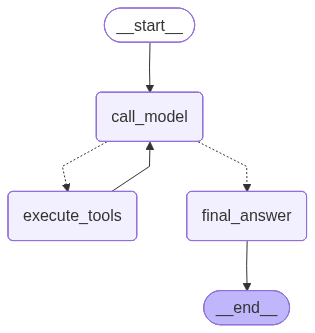

In [13]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("call_model", call_model_node)
graph_builder.add_node("execute_tools", execute_tools_node)
graph_builder.add_node("final_answer", final_answer_node)

graph_builder.add_edge(START, "call_model")
graph_builder.add_conditional_edges(
    "call_model",
    should_continue,
    {
        "execute_tools": "execute_tools",
        "final_answer": "final_answer",
    },
)
graph_builder.add_edge("execute_tools", "call_model")
graph_builder.add_edge("final_answer", END)

graph = graph_builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    display(Markdown("```mermaid\n" + graph.get_graph().draw_mermaid() + "\n```"))

## 15. Ejecucion real del grafo

Ejecutamos la consulta combinada usando Wikipedia e inventario.


In [14]:
initial_state = {
    "messages": [system_message, user_message],
    "final_answer": None,
}

graph_result = graph.invoke(initial_state)
display(graph_result["final_answer"])

'**¿Qué es un monitor LED?**\n\nUn monitor LED es una pantalla LCD que utiliza diodos emisores de luz (LED) como sistema de retroiluminación, en lugar de las lámparas fluorescentes tradicionales. Esta tecnología ofrece ventajas como mayor durabilidad, respuesta rápida, amplia gama de colores y es más respetuosa con el medio ambiente.\n\n**Stock e inventario:**\n\nEl producto "monitor LED" no se encuentra en el inventario con ese nombre exacto. Sin embargo, tenemos disponible un producto llamado **"monitor"**. ¿Deseas que consulte el precio y stock del monitor disponible?'

## 16. LangSmith: que mirar

LangSmith no cambia el codigo del agente: registra la ejecucion para auditar tool calls, argumentos, respuestas, latencia y salida final.


In [15]:
display({
    "project": os.getenv("LANGCHAIN_PROJECT"),
    "tracing_activo": os.getenv("LANGCHAIN_TRACING_V2") == "true",
    "que_mirar": [
        "tool calls",
        "argumentos enviados a cada tool",
        "respuesta de cada tool",
        "latencia por paso",
        "respuesta final",
    ],
})


{'project': 'NLP3-AgenticAI',
 'tracing_activo': True,
 'que_mirar': ['tool calls',
  'argumentos enviados a cada tool',
  'respuesta de cada tool',
  'latencia por paso',
  'respuesta final']}

## 17. Smoke test contra datos reales

Hacemos una validacion basica contra la fuente de verdad: el CSV de inventario. No es una metrica formal; sirve para detectar rapido si la respuesta incluye precio y stock esperados.


In [16]:
test_cases = [
    {"question": "Explica que es un monitor LED y decime stock y precio del monitor.", "product": "monitor"},
    {"question": "Explica que es un teclado y decime stock y precio del teclado.", "product": "teclado"},
]


def contains_number(text: str, number: int | float) -> bool:
    value = str(int(number)) if float(number).is_integer() else str(number)
    return re.search(rf"(?<!\d){re.escape(value)}(?!\d)", text) is not None


evaluation_rows = []

for case in test_cases:
    expected = consultar_inventario.invoke({"producto": case["product"]})
    result = graph.invoke({
        "messages": [system_message, HumanMessage(content=case["question"])],
        "final_answer": None,
    })

    answer = result["final_answer"]

    evaluation_rows.append({
        "pregunta": case["question"],
        "producto": case["product"],
        "precio_real": expected.get("precio"),
        "stock_real": expected.get("stock"),
        "respuesta_agente": answer,
        "contiene_precio": expected["encontrado"] and contains_number(answer, expected["precio"]),
        "contiene_stock": expected["encontrado"] and contains_number(answer, expected["stock"]),
    })

pd.DataFrame(evaluation_rows)

/home/lucianoceb/Documents/CEIA/PLN3/pln3/lib/python3.12/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /home/lucianoceb/Documents/CEIA/PLN3/pln3/lib/python3.12/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


,pregunta,producto,precio_real,stock_real,respuesta_agente,contiene_precio,contiene_stock
0,Explica que es un monitor LED y decime stock y...,monitor,300.0,6,**¿Qué es un Monitor LED?**\n\nUn monitor LED ...,False,False
1,Explica que es un teclado y decime stock y pre...,teclado,100.0,12,**¿Qué es un teclado?**\n\nUn teclado es un di...,True,True
